In [34]:
import rasterio
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [2]:
raster_path  = "/home/jovyan/MLFIM/data/processed/12090301/data_1/full_data.pkl"
df = pd.read_pickle(raster_path)

# Data Overview

In [3]:
df.describe()

,owp_hand_fim,lulc,slope,ndvi,curvature,aspect,rem,dem,flood_depth
count,7.701717e+07,1.402079e+08,1.402078e+08,1.402079e+08,1.402079e+08,1.402078e+08,7.701479e+07,1.402079e+08,2.239805e+06
mean,3.687759e-02,7.508244e+00,1.975536e+00,2.391795e-02,-8.411263e+04,1.726011e+02,1.364495e+01,1.307962e+02,1.622895e+00
std,3.592560e-01,3.913620e+00,2.047343e+00,4.871902e-01,5.751790e+09,1.238826e+02,1.051928e+01,6.498614e+01,1.978380e+00
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.162646e+12,-1.000000e+00,0.000000e+00,4.385000e+01,2.976417e-04
25%,0.000000e+00,2.000000e+00,7.755292e-01,0.000000e+00,-1.022131e+09,9.149302e+01,5.766754e+00,1.046012e+02,2.992229e-01
50%,0.000000e+00,1.100000e+01,1.481148e+00,0.000000e+00,6.336035e+07,1.678613e+02,1.160699e+01,1.267116e+02,7.901551e-01
75%,0.000000e+00,1.100000e+01,2.472659e+00,0.000000e+00,1.306718e+09,2.528944e+02,1.912751e+01,1.522316e+02,2.050751e+00
max,8.673000e+00,1.100000e+01,6.385421e+01,1.000000e+01,3.435135e+11,3.599999e+02,8.788171e+01,3.156355e+02,1.281035e+01


In [4]:
df.head()

,owp_hand_fim,lulc,slope,ndvi,curvature,aspect,rem,dem,flood_depth
0,NaN,7.0,NaN,0.0,-2.713104e+09,NaN,NaN,290.970428,NaN
1,NaN,7.0,0.617253,0.0,1.717493e+09,256.352020,NaN,291.162445,NaN
2,NaN,7.0,0.387883,0.0,-5.759385e+08,11.684489,NaN,291.163239,NaN
3,NaN,7.0,0.353164,0.0,-6.047710e+08,13.550080,NaN,291.154480,NaN
4,NaN,7.0,0.099389,0.0,-2.865454e+08,357.743683,NaN,291.145111,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140207891 entries, 0 to 140207890
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   owp_hand_fim  float32
 1   lulc          float32
 2   slope         float32
 3   ndvi          float32
 4   curvature     float32
 5   aspect        float32
 6   rem           float32
 7   dem           float32
 8   flood_depth   float32
dtypes: float32(9)
memory usage: 4.7 GB


# Missing Data Analysis

In [6]:
df.isnull().sum()

owp_hand_fim     63190725
lulc                    0
slope                  53
ndvi                    0
curvature               0
aspect                 53
rem              63193100
dem                     0
flood_depth     137968086
dtype: int64

In [3]:
df_rm_h = df.dropna(subset=["owp_hand_fim"])

In [4]:
df_rm_h.isnull().sum()

owp_hand_fim           0
lulc                   0
slope                  0
ndvi                   0
curvature              0
aspect                 0
rem                24620
dem                    0
flood_depth     74777426
dtype: int64

In [5]:
df_rm_h["rem"] = df_rm_h["rem"].fillna(df_rm_h["rem"].mean())

/tmp/ipykernel_1046/2402131232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rm_h["rem"] = df_rm_h["rem"].fillna(df_rm_h["rem"].mean())


In [12]:
df_rm_h.isnull().sum()

owp_hand_fim           0
lulc                   0
slope                  0
ndvi                   0
curvature              0
aspect                 0
rem                    0
dem                    0
flood_depth     74777426
dtype: int64

In [6]:
df_rm_h["flood_depth"] = df_rm_h["flood_depth"].fillna(0)

/tmp/ipykernel_1046/1792729537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rm_h["flood_depth"] = df_rm_h["flood_depth"].fillna(0)


In [7]:
df_rm_h.isnull().sum()

owp_hand_fim    0
lulc            0
slope           0
ndvi            0
curvature       0
aspect          0
rem             0
dem             0
flood_depth     0
dtype: int64

In [8]:
df_rm_h.describe()

,owp_hand_fim,lulc,slope,ndvi,curvature,aspect,rem,dem,flood_depth
count,7.701717e+07,7.701717e+07,7.701717e+07,7.701717e+07,7.701717e+07,7.701717e+07,7.701717e+07,7.701717e+07,7.701717e+07
mean,3.687747e-02,7.399739e+00,1.995525e+00,5.715025e-03,-4.119901e+05,1.739464e+02,1.364550e+01,1.337068e+02,4.719521e-02
std,3.592560e-01,3.733844e+00,2.037756e+00,2.333013e-01,6.163539e+09,1.072288e+02,1.051836e+01,6.564159e+01,4.310513e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.162646e+12,-1.000000e+00,0.000000e+00,4.460000e+01,0.000000e+00
25%,0.000000e+00,2.000000e+00,7.861326e-01,0.000000e+00,-1.023910e+09,9.240924e+01,5.769501e+00,1.098300e+02,0.000000e+00
50%,0.000000e+00,7.000000e+00,1.479089e+00,0.000000e+00,7.110242e+07,1.699360e+02,1.161182e+01,1.308603e+02,0.000000e+00
75%,0.000000e+00,1.100000e+01,2.472216e+00,0.000000e+00,1.320067e+09,2.548952e+02,1.912484e+01,1.560913e+02,0.000000e+00
max,8.673000e+00,1.100000e+01,5.964313e+01,1.000000e+01,3.435135e+11,3.599999e+02,8.788171e+01,2.848429e+02,1.281035e+01


array([[<Axes: title={'center': 'owp_hand_fim'}>,
        <Axes: title={'center': 'lulc'}>,
        <Axes: title={'center': 'slope'}>],
       [<Axes: title={'center': 'ndvi'}>,
        <Axes: title={'center': 'curvature'}>,
        <Axes: title={'center': 'aspect'}>],
       [<Axes: title={'center': 'rem'}>, <Axes: title={'center': 'dem'}>,
        <Axes: title={'center': 'flood_depth'}>]], dtype=object)

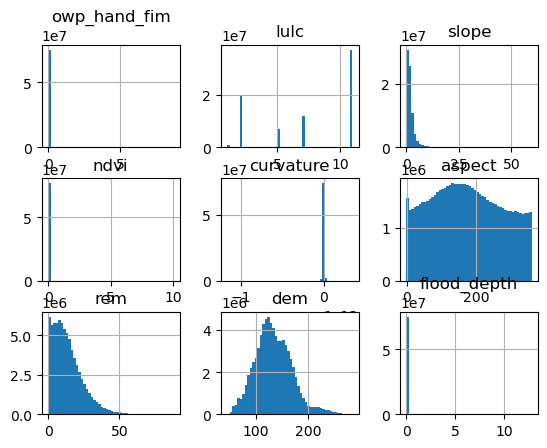

In [16]:
df_rm_h.hist(bins=50)

# Regression Model

In [9]:
THRESHOLD = 0.01
df_reg = df_rm_h[df_rm_h["flood_depth"] > THRESHOLD]

array([[<Axes: title={'center': 'owp_hand_fim'}>,
        <Axes: title={'center': 'lulc'}>,
        <Axes: title={'center': 'slope'}>],
       [<Axes: title={'center': 'ndvi'}>,
        <Axes: title={'center': 'curvature'}>,
        <Axes: title={'center': 'aspect'}>],
       [<Axes: title={'center': 'rem'}>, <Axes: title={'center': 'dem'}>,
        <Axes: title={'center': 'flood_depth'}>]], dtype=object)

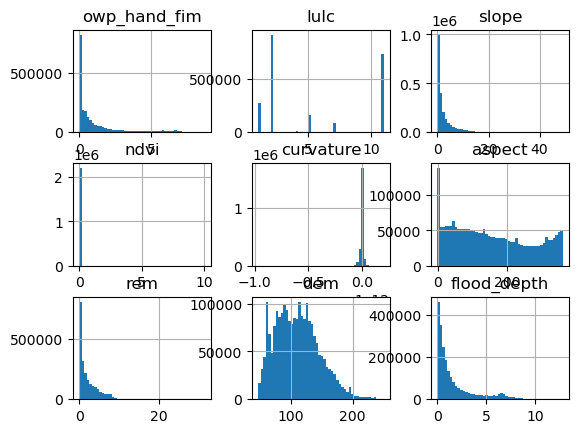

In [23]:
df_reg.hist(bins=50)

In [10]:
def plot_scatter_and_violin(y_true, y_pred, variable_name="Flood Depth"):
    y_true_np = np.array(y_true).reshape(-1, 1)
    y_pred_np = np.array(y_pred)

    # Fit regression line from origin
    reg_origin = LinearRegression(fit_intercept=False)
    reg_origin.fit(y_true_np, y_pred_np)

    # Ensure x_line starts at 0
    x_min = 0
    x_max = max(np.max(y_true), np.max(y_pred))
    x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
    y_line = reg_origin.predict(x_line)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scatter plot with ideal and fitted lines
    ax1 = axes[0]
    ax1.scatter(y_true, y_pred, alpha=0.4, s=10, edgecolors='k', linewidths=0.2)
    ax1.plot(x_line, y_line, color='red', linewidth=2, label='Fit from origin')
    ax1.plot(x_line, x_line, color='green', linestyle='--', linewidth=2.5, label='Ideal: y = x')  # thicker green line
    ax1.set_title("Predicted vs Actual (Scatter)")
    ax1.set_xlabel(f"Actual {variable_name}")
    ax1.set_ylabel(f"Predicted {variable_name}")
    ax1.set_xlim(left=0)
    ax1.set_ylim(bottom=0)
    ax1.legend()

    # Violin plot
    ax2 = axes[1]
    sns.violinplot(data=[y_true, y_pred], ax=ax2)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(["Actual", "Predicted"])
    ax2.set_title("Distribution of Actual vs Predicted")

    plt.tight_layout()
    plt.show()

# Model without any feature changing

In [35]:
# -------------------------------
# 1. Define features and target
# -------------------------------
features = [
    "owp_hand_fim", "lulc", "slope", "ndvi",
    "curvature", "aspect", "rem", "dem"
]
target = "flood_depth"

# -------------------------------
# 2. Prepare X and y
# -------------------------------
X = df_reg[features]
y = df_reg[target]

# Fill missing values with column mean (basic strategy for now)
X = X.fillna(X.mean())

# -------------------------------
# 3. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Train the model
# -------------------------------
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective="reg:squarederror",
    tree_method="hist",  # or 'gpu_hist' if using GPU
    verbosity=0
)

model.fit(X_train, y_train)

# -------------------------------
# 5. Evaluate on training set
# -------------------------------
y_train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
train_r2 = r2_score(y_train, y_train_pred)

print("📘 Training Set Performance")
print(f"MAE:  {train_mae:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²:   {train_r2:.4f}")

# -------------------------------
# 6. Evaluate on testing set
# -------------------------------
y_test_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
test_r2 = r2_score(y_test, y_test_pred)

print("\n📙 Testing Set Performance")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


📘 Training Set Performance
MAE:  0.3753
RMSE: 0.5753
R²:   0.9160

📙 Testing Set Performance
MAE:  0.3805
RMSE: 0.5860
R²:   0.9129


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


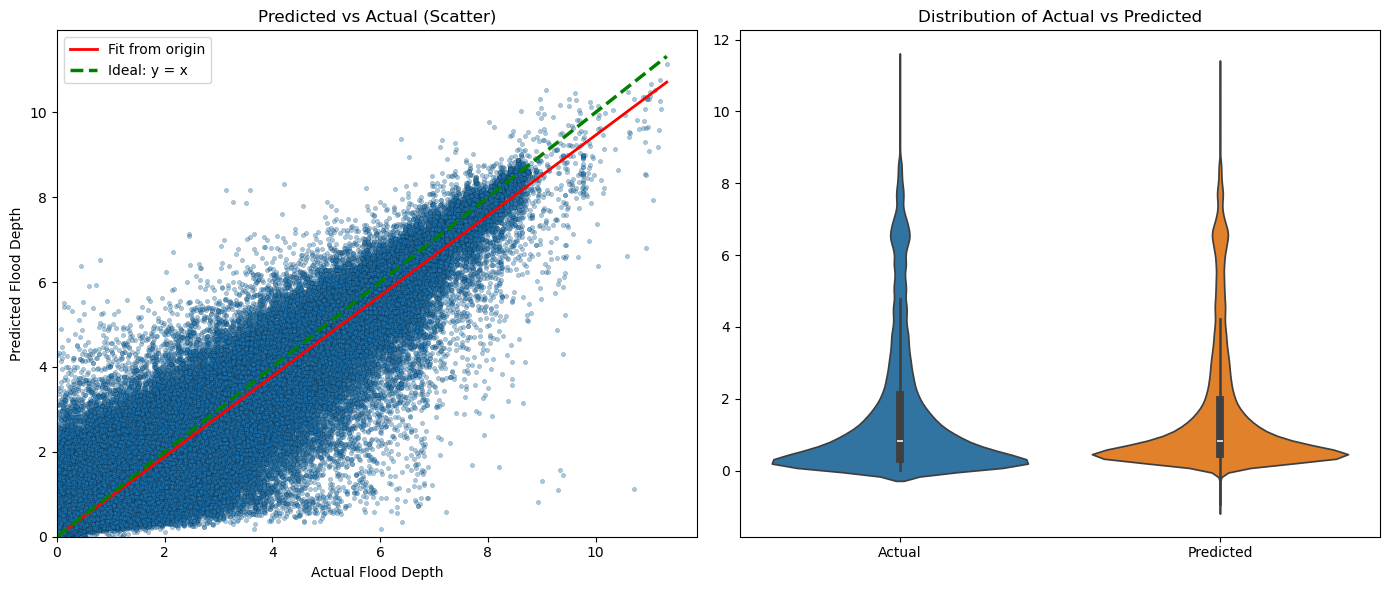

In [36]:
# Plot using test set results
plot_scatter_and_violin(y_test, y_test_pred, variable_name="Flood Depth")

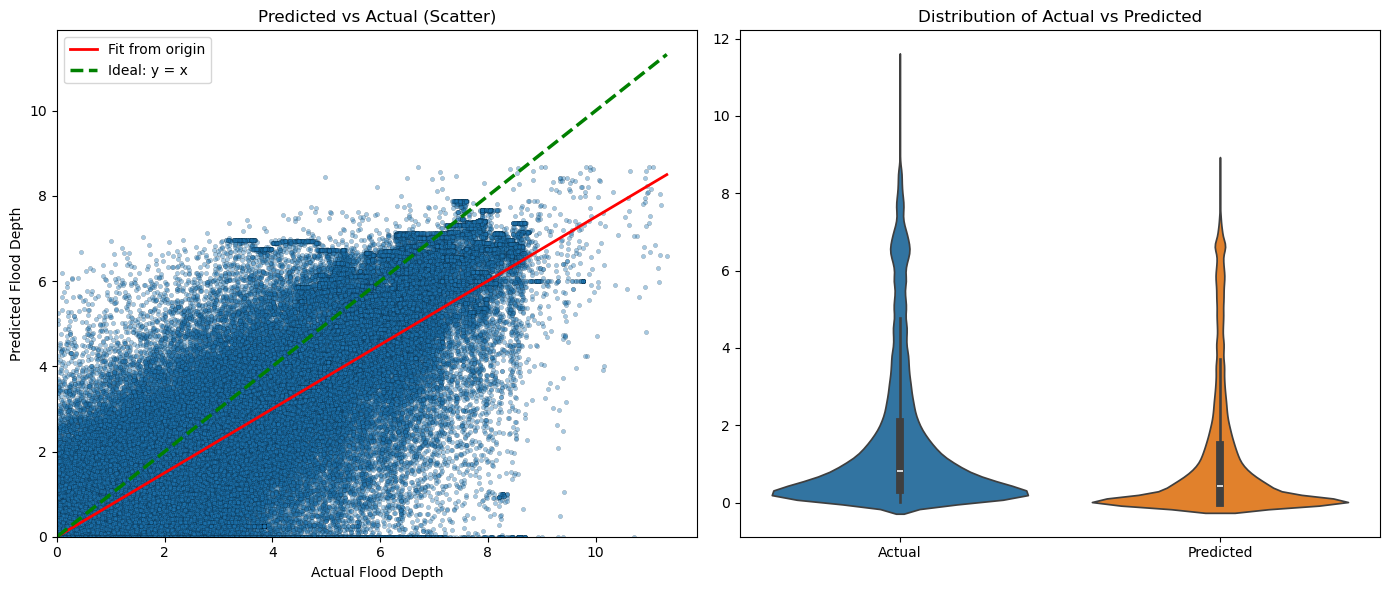

In [38]:
# Plot using test set results
plot_scatter_and_violin(y_test, X_test["owp_hand_fim"], variable_name="Flood Depth")

# Aspect sin_cos

In [39]:

# -------------------------------
# 1. Add sin/cos of aspect to df
# -------------------------------
df_reg_temp = df_reg.copy()
df_reg_temp["aspect_sin"] = np.sin(np.deg2rad(df_reg_temp["aspect"]))
df_reg_temp["aspect_cos"] = np.cos(np.deg2rad(df_reg_temp["aspect"]))

# -------------------------------
# 2. Define features and target
# -------------------------------
features_temp = [
    "owp_hand_fim", "lulc", "slope", "ndvi",
    "curvature", "aspect_sin", "aspect_cos", "rem", "dem"
]
target_temp = "flood_depth"

# -------------------------------
# 3. Prepare X and y
# -------------------------------
X_temp = df_reg_temp[features_temp].copy()
y_temp = df_reg_temp[target_temp].copy()

# Fill missing values with column mean (safe basic strategy)
X_temp = X_temp.fillna(X_temp.mean())

# -------------------------------
# 4. Train-test split
# -------------------------------
X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Train XGBoost model
# -------------------------------
model_temp = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective="reg:squarederror",
    tree_method="hist",  # use 'gpu_hist' if using GPU
    verbosity=0
)

model_temp.fit(X_temp_train, y_temp_train)

# -------------------------------
# 6. Evaluate on training set
# -------------------------------
y_temp_train_pred = model_temp.predict(X_temp_train)
mae_train_temp = mean_absolute_error(y_temp_train, y_temp_train_pred)
rmse_train_temp = mean_squared_error(y_temp_train, y_temp_train_pred, squared=False)
r2_train_temp = r2_score(y_temp_train, y_temp_train_pred)

print("📘 Training Set Performance (With Sin/Cos Aspect)")
print(f"MAE:  {mae_train_temp:.4f}")
print(f"RMSE: {rmse_train_temp:.4f}")
print(f"R²:   {r2_train_temp:.4f}")

# -------------------------------
# 7. Evaluate on test set
# -------------------------------
y_temp_test_pred = model_temp.predict(X_temp_test)
mae_test_temp = mean_absolute_error(y_temp_test, y_temp_test_pred)
rmse_test_temp = mean_squared_error(y_temp_test, y_temp_test_pred, squared=False)
r2_test_temp = r2_score(y_temp_test, y_temp_test_pred)

print("\n📙 Testing Set Performance (With Sin/Cos Aspect)")
print(f"MAE:  {mae_test_temp:.4f}")
print(f"RMSE: {rmse_test_temp:.4f}")
print(f"R²:   {r2_test_temp:.4f}")


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


📘 Training Set Performance (With Sin/Cos Aspect)
MAE:  0.3756
RMSE: 0.5746
R²:   0.9162

📙 Testing Set Performance (With Sin/Cos Aspect)
MAE:  0.3811
RMSE: 0.5860
R²:   0.9129


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


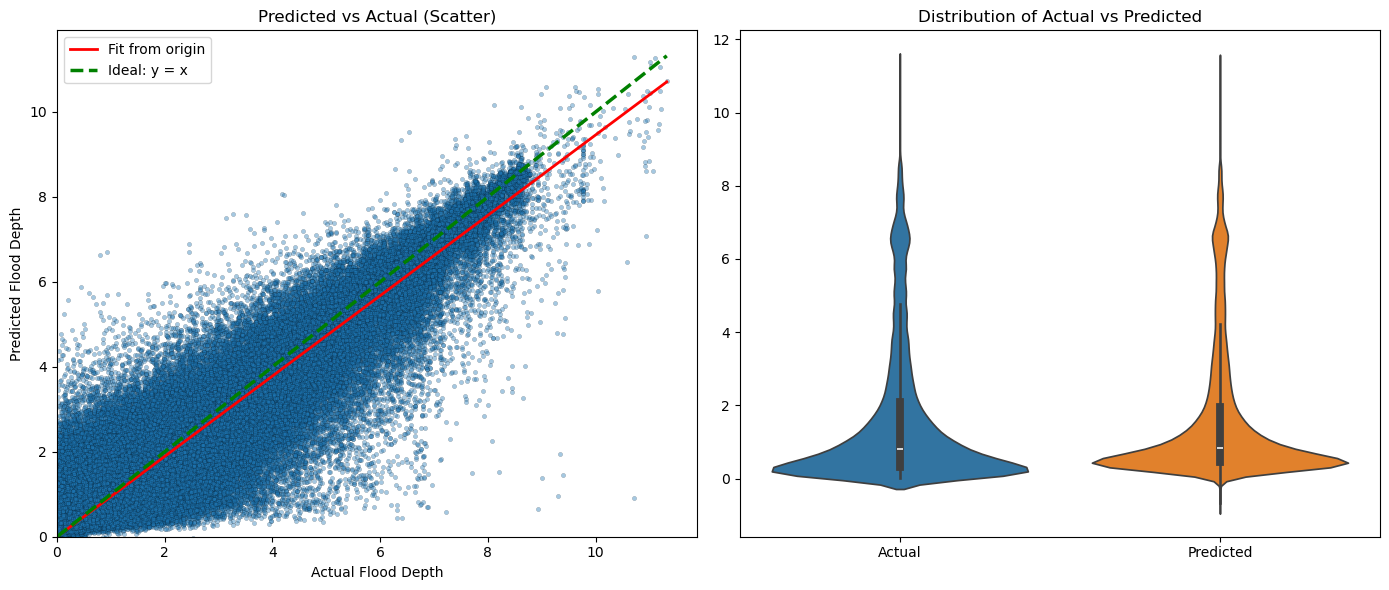

In [40]:
# Plot using the updated test set and predictions
plot_scatter_and_violin(
    y_true=y_temp_test,
    y_pred=y_temp_test_pred,
    variable_name="Flood Depth"
)


## using log and aspect_sin_cos

In [41]:
df_reg.describe()

,owp_hand_fim,lulc,slope,ndvi,curvature,aspect,rem,dem,flood_depth
count,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06
mean,1.191848e+00,5.316673e+00,2.612460e+00,2.728605e-05,-1.796998e+09,1.553948e+02,2.080319e+00,1.107910e+02,1.652911e+00
std,1.766647e+00,4.258364e+00,3.599555e+00,1.651845e-02,1.314687e+10,1.096499e+02,2.294335e+00,3.505851e+01,1.983923e+00
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-9.657627e+11,-1.000000e+00,0.000000e+00,4.775000e+01,1.000355e-02
25%,0.000000e+00,2.000000e+00,4.356169e-01,0.000000e+00,-3.736781e+09,5.916082e+01,2.993622e-01,8.331539e+01,3.188115e-01
50%,4.249724e-01,2.000000e+00,1.163545e+00,0.000000e+00,-1.471882e+08,1.389748e+02,1.189442e+00,1.086473e+02,8.162336e-01
75%,1.474349e+00,1.100000e+01,3.236887e+00,0.000000e+00,1.883458e+09,2.452185e+02,3.253235e+00,1.332421e+02,2.097559e+00
max,8.673000e+00,1.100000e+01,4.903083e+01,1.000000e+01,2.025308e+11,3.599999e+02,3.147142e+01,2.497273e+02,1.281035e+01


In [11]:
# -------------------------------
# 1. Prepare transformed dataframe
# -------------------------------
df_reg_v2 = df_reg.copy()

# Aspect → sin/cos
df_reg_v2["aspect_sin"] = np.sin(np.deg2rad(df_reg_v2["aspect"]))
df_reg_v2["aspect_cos"] = np.cos(np.deg2rad(df_reg_v2["aspect"]))

# Log1p transform skewed features
df_reg_v2["owp_hand_fim_log"] = np.log1p(df_reg_v2["owp_hand_fim"])
df_reg_v2["slope_log"] = np.log1p(df_reg_v2["slope"])
df_reg_v2["rem_log"] = np.log1p(df_reg_v2["rem"])
df_reg_v2["flood_depth_log"] = np.log1p(df_reg_v2["flood_depth"])


In [13]:
df_reg_v2.describe()

,owp_hand_fim,lulc,slope,ndvi,curvature,aspect,rem,dem,flood_depth,aspect_sin,aspect_cos,owp_hand_fim_log,slope_log,rem_log,flood_depth_log
count,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06,2.198926e+06
mean,1.191848e+00,5.316673e+00,2.612460e+00,2.728605e-05,-1.796998e+09,1.553948e+02,2.080319e+00,1.107910e+02,1.652911e+00,1.324961e-01,1.019408e-01,5.599669e-01,9.591644e-01,8.817644e-01,7.667699e-01
std,1.766647e+00,4.258364e+00,3.599555e+00,1.651845e-02,1.314687e+10,1.096499e+02,2.294335e+00,3.505851e+01,1.983923e+00,6.653268e-01,7.266610e-01,6.157668e-01,7.477289e-01,6.831250e-01,6.056473e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-9.657627e+11,-1.000000e+00,0.000000e+00,4.775000e+01,1.000355e-02,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.953848e-03
25%,0.000000e+00,2.000000e+00,4.356169e-01,0.000000e+00,-3.736781e+09,5.916082e+01,2.993622e-01,8.331539e+01,3.188115e-01,-4.589566e-01,-6.435239e-01,0.000000e+00,3.615946e-01,2.618735e-01,2.767310e-01
50%,4.249724e-01,2.000000e+00,1.163545e+00,0.000000e+00,-1.471882e+08,1.389748e+02,1.189442e+00,1.086473e+02,8.162336e-01,1.894241e-01,1.984218e-01,3.541524e-01,7.717479e-01,7.836466e-01,5.967650e-01
75%,1.474349e+00,1.100000e+01,3.236887e+00,0.000000e+00,1.883458e+09,2.452185e+02,3.253235e+00,1.332421e+02,2.097559e+00,7.707521e-01,8.359704e-01,9.059773e-01,1.443829e+00,1.447680e+00,1.130614e+00
max,8.673000e+00,1.100000e+01,4.903083e+01,1.000000e+01,2.025308e+11,3.599999e+02,3.147142e+01,2.497273e+02,1.281035e+01,1.000000e+00,1.000000e+00,2.269339e+00,3.912639e+00,3.480360e+00,2.625418e+00


array([[<Axes: title={'center': 'owp_hand_fim'}>,
        <Axes: title={'center': 'lulc'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ndvi'}>],
       [<Axes: title={'center': 'curvature'}>,
        <Axes: title={'center': 'aspect'}>,
        <Axes: title={'center': 'rem'}>, <Axes: title={'center': 'dem'}>],
       [<Axes: title={'center': 'flood_depth'}>,
        <Axes: title={'center': 'aspect_sin'}>,
        <Axes: title={'center': 'aspect_cos'}>,
        <Axes: title={'center': 'owp_hand_fim_log'}>],
       [<Axes: title={'center': 'slope_log'}>,
        <Axes: title={'center': 'rem_log'}>,
        <Axes: title={'center': 'flood_depth_log'}>, <Axes: >]],
      dtype=object)

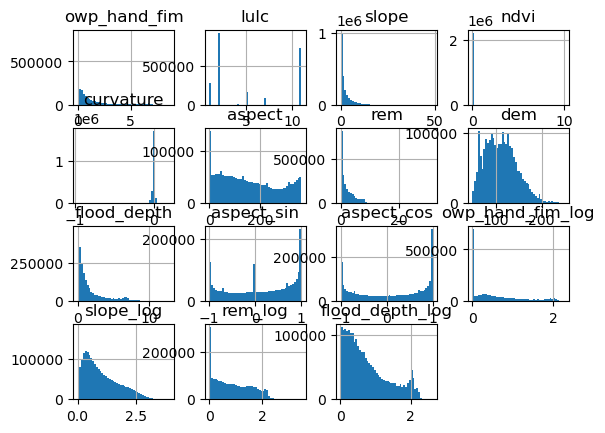

In [14]:
df_reg_v2.hist(bins=50)

In [19]:
# -------------------------------
# 1. Define features and target
# -------------------------------
features_v2 = [
    "owp_hand_fim", "lulc", "slope",
    "curvature", "aspect_sin", "aspect_cos", "rem", "dem"
]
target_v2 = "flood_depth_log"  # still using log target

# -------------------------------
# 2. Prepare X, y, and sample weights
# -------------------------------
X_v2 = df_reg_v2[features_v2].copy()
y_v2 = df_reg_v2[target_v2].copy()

# Fill missing values
X_v2 = X_v2.fillna(X_v2.mean())

# Define sample weights (add small epsilon to avoid 0)
sample_weights = df_reg_v2["flood_depth"] + 0.1

# -------------------------------
# 3. Train-test split
# -------------------------------
X_train_v2, X_test_v2, y_train_v2, y_test_v2, w_train, w_test = train_test_split(
    X_v2, y_v2, sample_weights, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Train XGBoost model with weights
# -------------------------------
model_v2 = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective="reg:squarederror",
    tree_method="hist",  # use 'gpu_hist' if available
    verbosity=0
)

model_v2.fit(X_train_v2, y_train_v2, sample_weight=w_train)

# -------------------------------
# 5. Evaluate on training set
# -------------------------------
y_train_pred_log_v2 = model_v2.predict(X_train_v2)
y_train_pred_v2 = np.expm1(y_train_pred_log_v2)
y_train_actual_v2 = np.expm1(y_train_v2)

mae_train_v2 = mean_absolute_error(y_train_actual_v2, y_train_pred_v2)
rmse_train_v2 = mean_squared_error(y_train_actual_v2, y_train_pred_v2, squared=False)
r2_train_v2 = r2_score(y_train_actual_v2, y_train_pred_v2)

print("📘 Training Set Performance (w/ sample weights)")
print(f"MAE:  {mae_train_v2:.4f}")
print(f"RMSE: {rmse_train_v2:.4f}")
print(f"R²:   {r2_train_v2:.4f}")

# -------------------------------
# 6. Evaluate on test set
# -------------------------------
y_test_pred_log_v2 = model_v2.predict(X_test_v2)
y_test_pred_v2 = np.expm1(y_test_pred_log_v2)
y_test_actual_v2 = np.expm1(y_test_v2)

mae_test_v2 = mean_absolute_error(y_test_actual_v2, y_test_pred_v2)
rmse_test_v2 = mean_squared_error(y_test_actual_v2, y_test_pred_v2, squared=False)
r2_test_v2 = r2_score(y_test_actual_v2, y_test_pred_v2)

print("\n📙 Testing Set Performance (w/ sample weights)")
print(f"MAE:  {mae_test_v2:.4f}")
print(f"RMSE: {rmse_test_v2:.4f}")
print(f"R²:   {r2_test_v2:.4f}")

/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


📘 Training Set Performance (w/ sample weights)
MAE:  0.4292
RMSE: 0.6186
R²:   0.9029

📙 Testing Set Performance (w/ sample weights)
MAE:  0.4350
RMSE: 0.6297
R²:   0.8994


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


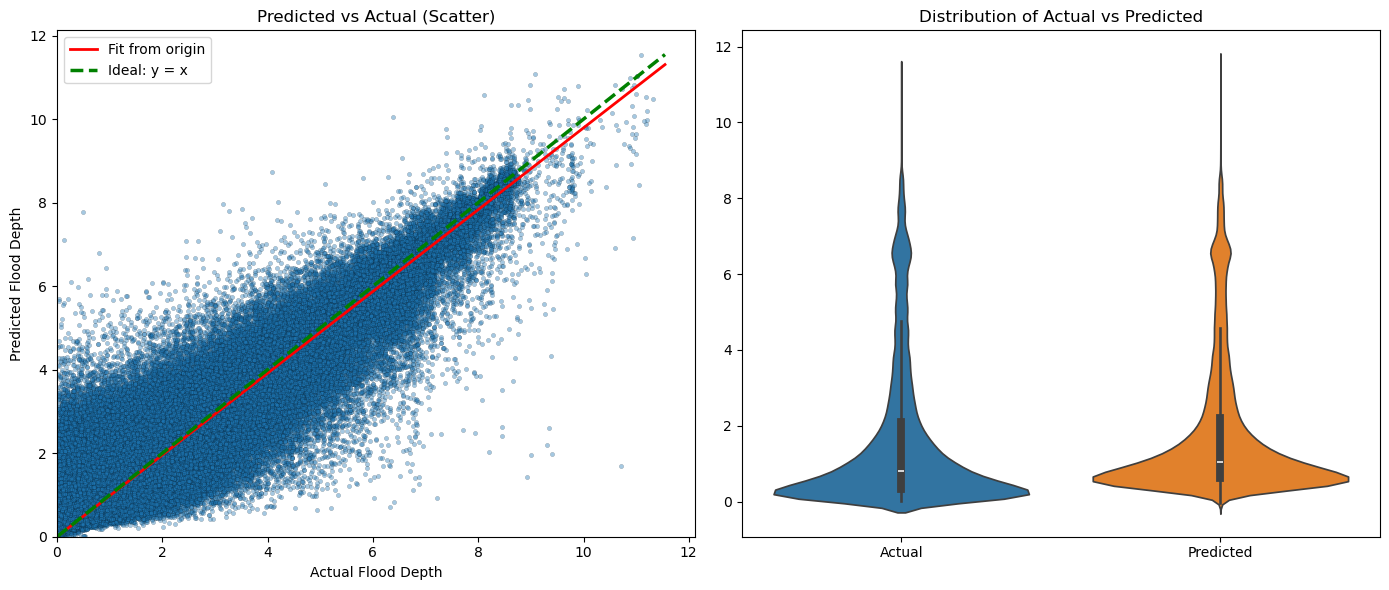

In [20]:
# Plot using updated test set results from model_v2
plot_scatter_and_violin(
    y_true=y_test_actual_v2,     # de-log-transformed actual flood depth
    y_pred=y_test_pred_v2,       # de-log-transformed predicted flood depth
    variable_name="Flood Depth"
)


In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Map LULC codes to names
#https://www.arcgis.com/home/item.html?id=cfcb7609de5f478eb7666240902d4d3d
lulc_label_map = {
    1: "Water",
    2: "Trees / Forest",
    3: "Grassland",
    4: "Flooded Vegetation",
    5: "Crops",
    6: "Shrubland",
    7: "Built-up / Urban",
    8: "Bare / Sparse Vegetation",
    9: "Snow / Ice",
    10: "Clouds",
    11: "Rangeland"
}

# 2. Prepare evaluation DataFrame
df_eval_lulc = X_test_v2.copy()
df_eval_lulc["lulc"] = df_reg_v2.loc[X_test_v2.index, "lulc"]
df_eval_lulc["actual_flood_depth"] = y_test_actual_v2
df_eval_lulc["predicted_flood_depth"] = y_test_pred_v2

# 3. Group by LULC and compute RMSE and R²
metrics_by_lulc = df_eval_lulc.groupby("lulc").apply(
    lambda g: pd.Series({
        "RMSE": mean_squared_error(g["actual_flood_depth"], g["predicted_flood_depth"], squared=False),
        "R2": r2_score(g["actual_flood_depth"], g["predicted_flood_depth"])
    })
).reset_index()

# 4. Add LULC label column
metrics_by_lulc["LULC Name"] = metrics_by_lulc["lulc"].map(lulc_label_map)

# 5. Reorder columns
metrics_by_lulc = metrics_by_lulc[["lulc", "LULC Name", "RMSE", "R2"]]

# 6. Sort by LULC ID for readability
metrics_by_lulc = metrics_by_lulc.sort_values("lulc").reset_index(drop=True)

# 7. Display
print(metrics_by_lulc)


   lulc                 LULC Name      RMSE        R2
0   1.0                     Water  0.536138  0.962712
1   2.0            Trees / Forest  0.758653  0.765965
2   4.0        Flooded Vegetation  0.481892  0.924807
3   5.0                     Crops  0.486855  0.868672
4   7.0          Built-up / Urban  0.630654  0.713342
5   8.0  Bare / Sparse Vegetation  0.508712  0.929699
6  11.0          Wetlands / Marsh  0.501190  0.799799


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To cal

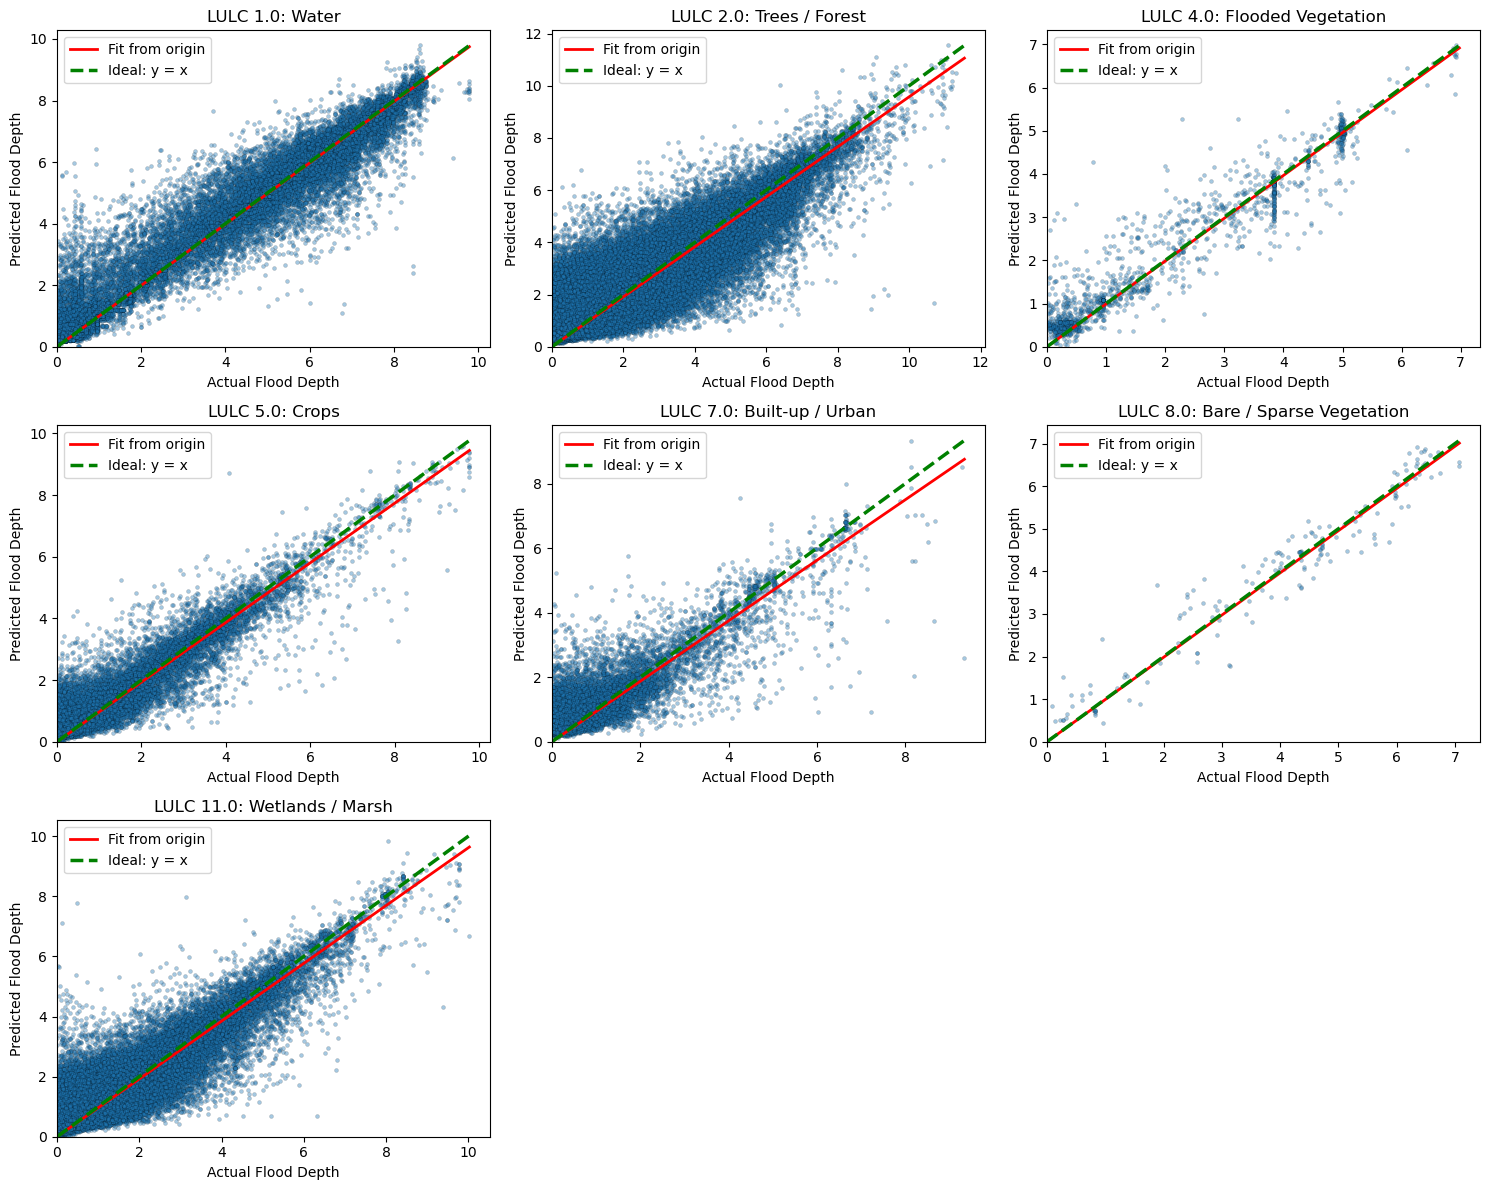

In [22]:
# 1. Get list of LULC categories present in test set
lulc_categories = sorted(df_eval_lulc["lulc"].unique())
n_categories = len(lulc_categories)

# 2. Setup grid layout (3 columns)
cols = 3
rows = int(np.ceil(n_categories / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# 3. Loop through each LULC category
for i, lulc_val in enumerate(lulc_categories):
    ax = axes[i]
    
    # Filter data for this category
    subset = df_eval_lulc[df_eval_lulc["lulc"] == lulc_val]
    y_true = subset["actual_flood_depth"].values.reshape(-1, 1)
    y_pred = subset["predicted_flood_depth"].values

    # Fit regression line from origin
    reg = LinearRegression(fit_intercept=False)
    reg.fit(y_true, y_pred)
    
    x_line = np.linspace(0, max(y_true.max(), y_pred.max()), 100).reshape(-1, 1)
    y_line = reg.predict(x_line)

    # Scatter
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, edgecolors='k', linewidths=0.2)
    ax.plot(x_line, y_line, color='red', linewidth=2, label="Fit from origin")
    ax.plot(x_line, x_line, color='green', linestyle='--', linewidth=2.5, label="Ideal: y = x")

    # Titles and labels
    ax.set_title(f"LULC {lulc_val}: {lulc_label_map.get(lulc_val, 'Unknown')}")
    ax.set_xlabel("Actual Flood Depth")
    ax.set_ylabel("Predicted Flood Depth")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.legend()

# Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Log target, stratified, aspect sin/cos, weights

In [25]:
# -------------------------------
# 1. Define features and target
# -------------------------------
features_final = [
    "owp_hand_fim", "lulc", "slope",
    "curvature", "aspect_sin", "aspect_cos", "rem", "dem"
]
target_final = "flood_depth_log"  # still using log target

# -------------------------------
# 2. Prepare X, y, and sample weights
# -------------------------------
X_final = df_reg_v2[features_final].copy()
y_final = df_reg_v2[target_final].copy()

# Fill missing values
X_final = X_final.fillna(X_final.mean())

# Define sample weights (add small epsilon to avoid 0)
weights_final = df_reg_v2["flood_depth"] + 0.1

# -------------------------------
# 3. Stratified splitting using binned target
# -------------------------------
bins = [0.01, 0.1, 0.5, 1, 2, 4, 6, 8, 10, df_reg_v2["flood_depth"].max()]
y_strat_bins = pd.cut(df_reg_v2["flood_depth"], bins=bins, labels=False)

# First: train vs temp (val+test) — returns 8 values
X_train_full, X_temp, y_train_full, y_temp, w_train_full, w_temp, strat_train, strat_temp = train_test_split(
    X_final, y_final, weights_final, y_strat_bins,
    test_size=0.3, stratify=y_strat_bins, random_state=42
)

# Then: temp → val and test (50/50 split)
X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(
    X_temp, y_temp, w_temp,
    test_size=0.5, stratify=strat_temp, random_state=42
)


In [33]:
print("Training: ", len(X_train_full))
print("Testing: ", len(X_test))
print("Validation: ", len(X_val))

Training:  1539248
Testing:  329839
Validation:  329839


In [38]:
# -------------------------------
# 4. Train XGBoost model with weights
# -------------------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective="reg:squarederror",
    tree_method="hist",
    verbosity=0
)

xgb_model.fit(X_train_full, y_train_full, sample_weight=w_train_full)

# -------------------------------
# 5. Evaluate on training set
# -------------------------------
y_train_pred_log = xgb_model.predict(X_train_full)
y_train_pred = np.expm1(y_train_pred_log)
y_train_actual = np.expm1(y_train_full)

mae_train = mean_absolute_error(y_train_actual, y_train_pred)
rmse_train = mean_squared_error(y_train_actual, y_train_pred, squared=False)
r2_train = r2_score(y_train_actual, y_train_pred)

print("📘 Training Set Performance")
print(f"MAE:  {mae_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R²:   {r2_train:.4f}")

# -------------------------------
# 6. Evaluate on test set
# -------------------------------
y_test_pred_log = xgb_model.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)
y_test_actual = np.expm1(y_test)

mae_test = mean_absolute_error(y_test_actual, y_test_pred)
rmse_test = mean_squared_error(y_test_actual, y_test_pred, squared=False)
r2_test = r2_score(y_test_actual, y_test_pred)

print("\n📙 Testing Set Performance")
print(f"MAE:  {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²:   {r2_test:.4f}")


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


📘 Training Set Performance
MAE:  0.4281
RMSE: 0.6165
R²:   0.9036

📙 Testing Set Performance
MAE:  0.4350
RMSE: 0.6303
R²:   0.8991


/srv/conda/envs/notebook/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


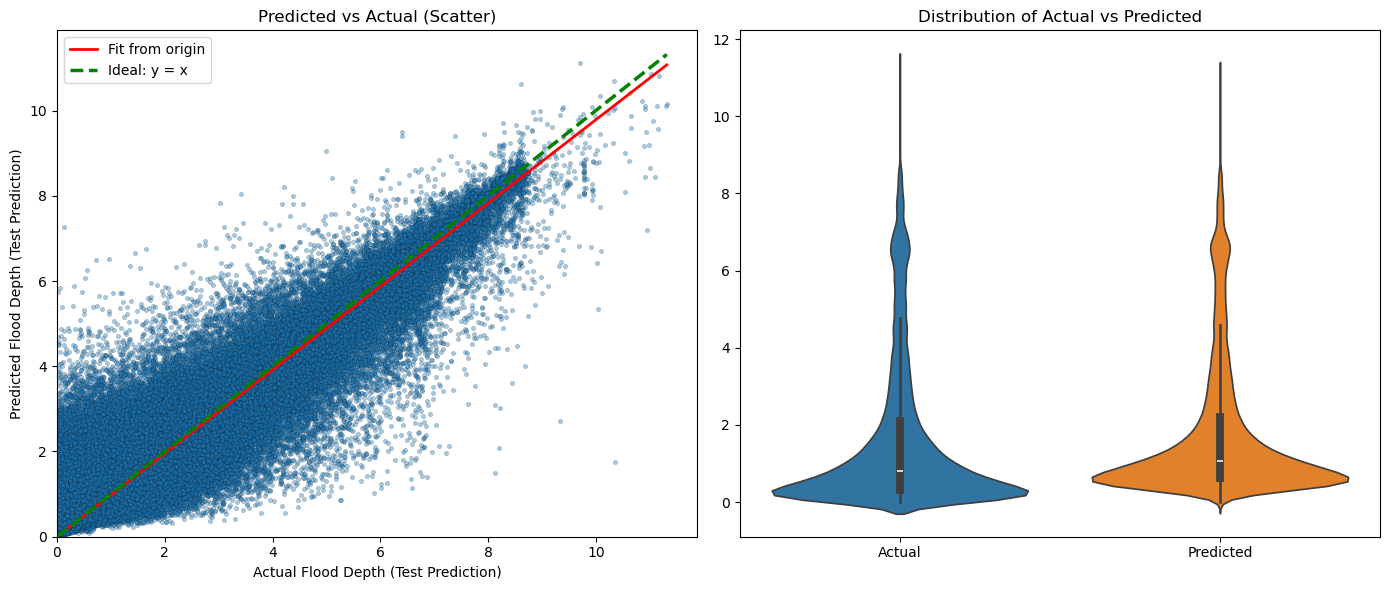

In [39]:
plot_scatter_and_violin(
    y_true=y_test_actual,
    y_pred=y_test_pred,
    variable_name="Flood Depth (Test Prediction)"
)
